# 01 · The Laplace–Beltrami operator: the engine under SpectralBrain

**SpectralBrain tutorial series — notebook 1 of 10.**

| # | Notebook | You are here |
|---|----------|:---:|
| 01 | **The Laplace–Beltrami operator** | 👈 |
| 02 | Reading real brains: the I/O layer | |
| 03 | ShapeDNA: hearing the shape of a hippocampus | |
| 04 | The Heat Kernel Signature | |
| 05 | Wave Kernel Signature & Global Point Signature | |
| 06 | Point clouds & white-matter tracts | |
| 07 | Functional maps & shape distances | |
| 08 | Cohorts & vertex-wise statistics | |
| 09 | Effect sizes, classification, harmonization | |
| 10 | Bayesian spectral analysis & visualization | |

Every descriptor in SpectralBrain (ShapeDNA, HKS, WKS, GPS, …) is computed from
one object: the **spectrum of the Laplace–Beltrami operator (LBO)** of a surface.
If you understand the LBO, you understand the whole library. This notebook builds
that understanding from the ground up, on a **real hippocampus**.

### Learning objectives
1. State the eigenvalue problem $\Delta\varphi = -\lambda\varphi$ and what eigenvalues/eigenfunctions *mean*.
2. Compute the LBO spectrum of a real surface with `mesh.decompose(k)`.
3. See why low-index eigenfunctions are smooth and high-index ones oscillate.
4. Verify two deep facts numerically: **Weyl's law** and **isometry invariance**.


## 1. Shape as vibration

In 1966 Mark Kac asked: *"Can one hear the shape of a drum?"* A drumhead vibrates
at a discrete set of frequencies fixed entirely by its shape. Those frequencies
are the **eigenvalues of the Laplacian**, and the vibration patterns are its
**eigenfunctions**. Spectral shape analysis turns Kac's question around: we
*listen* to a brain structure's natural frequencies and use them as a fingerprint
of its geometry.

### The operator
On a smooth surface $\mathcal{S}$ with Riemannian metric $g$, the
Laplace–Beltrami operator generalises the familiar Laplacian to curved space:

$$\Delta f = \tfrac{1}{\sqrt{|g|}}\,\partial_i\!\left(\sqrt{|g|}\,g^{ij}\,\partial_j f\right).$$

We seek functions that the operator only rescales — the **eigenfunctions** $\varphi_k$:

$$\Delta \varphi_k = -\lambda_k \varphi_k, \qquad 0 = \lambda_0 \le \lambda_1 \le \lambda_2 \le \cdots$$

The non-negative numbers $\lambda_k$ are squared spatial frequencies: small
$\lambda$ = slow, smooth variation; large $\lambda$ = rapid oscillation.

### The discrete operator (what the computer actually solves)
A triangular mesh has no smooth metric, so SpectralBrain uses the **cotangent
discretization** (Pinkall–Polthier; Meyer et al. 2003). It produces two sparse
matrices: a **stiffness** matrix $L$ (the discrete $-\Delta$, built from cotangents
of triangle angles) and a **mass** matrix $M$ (vertex areas). The eigenproblem
becomes *generalised*:

$$L\,\varphi_k = \lambda_k\, M\,\varphi_k.$$

Crucially, $L$ and $M$ depend only on **edge lengths and angles** — intrinsic
quantities. Rotating or translating the brain in space does not change them, so
the spectrum is **invariant to pose**. We will prove this to ourselves at the end.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # so `_tutorial_utils` is importable

import numpy as np
import matplotlib.pyplot as plt
import spectralbrain as sb
from _tutorial_utils import data_path, spectrum_plot

np.set_printoptions(precision=4, suppress=True)

# A real hippocampus: HippUnfold v2 den-8k midthickness surface (subject 03, left).
gii = data_path("hippunfold", "sub03", "hemi-L_space-T1w_den-8k_label-hipp_midthickness.surf.gii")
verts, faces = sb.load_gifti_surface(gii)
hipp = sb.BrainMesh(verts, faces)

print(f"vertices ......... {hipp.n_vertices:,}")
print(f"faces ............ {hipp.n_faces:,}")
print(f"surface area ..... {hipp.surface_area():.1f} mm^2")
print(f"closed surface? .. {hipp.is_closed()}")
print(f"Euler characteristic {hipp.euler_characteristic()}  (genus {hipp.genus()})")

vertices ......... 8,192
faces ............ 16,002
surface area ..... 865.0 mm^2
closed surface? .. False
Euler characteristic 1  (genus 0)


## 2. Computing the spectrum

`mesh.decompose(k)` assembles $L$ and $M$ and solves the generalised eigenproblem
for the **smallest** $k$ eigenvalues (the low frequencies carry the shape
information; high frequencies are noise — a theme of notebook 10). It returns a
decomposition object exposing `.eigenvalues` $(k,)$ and `.eigenvectors`
$(N, k)$ — the discrete $\varphi_k$ sampled at the $N$ vertices.

In [2]:
dec = hipp.decompose(k=100)
print("first 8 eigenvalues:")
print(dec.eigenvalues[:8])
print(f"\nlambda_0 = {dec.eigenvalues[0]:.3e}   (should be ~0: the constant mode)")
print(f"eigenvectors shape: {dec.eigenvectors.shape}   (N_vertices x k)")
print(f"spectral gap (lambda_1 - lambda_0): {dec.spectral_gap:.3e}")

[06/09/26 01:54:26] INFO     Laplacian (cotangent): N=8192, nnz=56578

first 8 eigenvalues:
[0.     0.0058 0.0217 0.03   0.0393 0.0495 0.0587 0.0789]

lambda_0 = 3.990e-17   (should be ~0: the constant mode)
eigenvectors shape: (8192, 100)   (N_vertices x k)
spectral gap (lambda_1 - lambda_0): 1.590e-02


### Why $\lambda_0 = 0$
A constant function has zero gradient, so $\Delta(\text{const}) = 0$. The constant
is therefore always the first eigenfunction, with eigenvalue exactly $0$. It
carries no shape information and is usually skipped by descriptors. Let us confirm
$\varphi_0$ is (numerically) constant and look at the spectrum.

phi_0: mean=-0.0340, std=7.21e-16  -> essentially constant


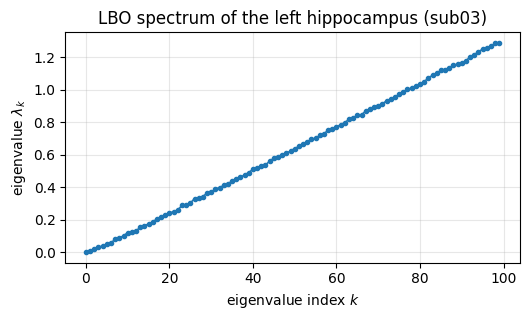

In [3]:
phi0 = dec.eigenvectors[:, 0]
print(f"phi_0: mean={phi0.mean():.4f}, std={phi0.std():.2e}  -> essentially constant")

fig, ax = plt.subplots(figsize=(5.4, 3.3))
spectrum_plot(dec.eigenvalues, ax=ax)
ax.set_title("LBO spectrum of the left hippocampus (sub03)")
plt.tight_layout(); plt.show()

## 3. Eigenfunctions are vibration modes

Each $\varphi_k$ paints a smooth pattern of highs and lows on the surface. The
curves where $\varphi_k = 0$ are its **nodal sets** (the "still" lines of the
drum). As $k$ grows, the modes oscillate faster and the nodal sets multiply —
exactly the behaviour of higher harmonics on an instrument.

Below we colour the mesh vertices by the first six eigenfunctions. Watch the
pattern go from a single smooth gradient ($\varphi_1$, the *Fiedler vector*) to
ever finer oscillations.

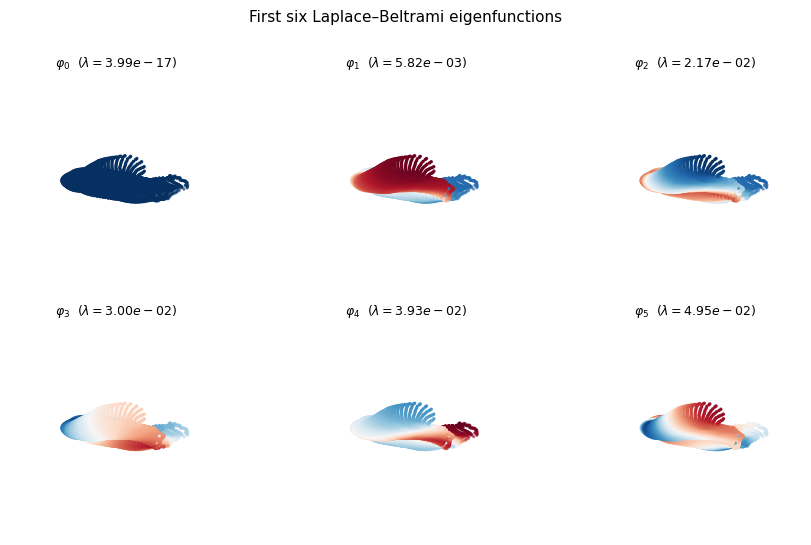

In [4]:
def scatter_modes(mesh, dec, n=6, ncols=3):
    V = mesh.vertices
    nrows = int(np.ceil(n / ncols))
    fig = plt.figure(figsize=(ncols * 3.0, nrows * 2.7))
    for i in range(n):
        ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
        s = dec.eigenvectors[:, i]
        ax.scatter(V[:, 0], V[:, 1], V[:, 2], c=s, cmap="RdBu_r", s=2,
                   vmin=-np.abs(s).max(), vmax=np.abs(s).max())
        ax.set_title(rf"$\varphi_{{{i}}}$  ($\lambda={dec.eigenvalues[i]:.2e}$)", fontsize=9)
        ax.set_axis_off(); ax.view_init(elev=20, azim=-70)
    fig.suptitle("First six Laplace–Beltrami eigenfunctions", y=1.0, fontsize=11)
    plt.tight_layout(); return fig

scatter_modes(hipp, dec, n=6); plt.show()

The same low-frequency mode, rendered properly with SpectralBrain's
template-free six-view renderer (the tool we examine in depth in notebook 10).
$\varphi_1$ separates the hippocampal head from the tail — the dominant axis of
the shape, recovered automatically from geometry alone.

2026-06-09 01:54:47.568 (  14.676s) [    7F1F45D63080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


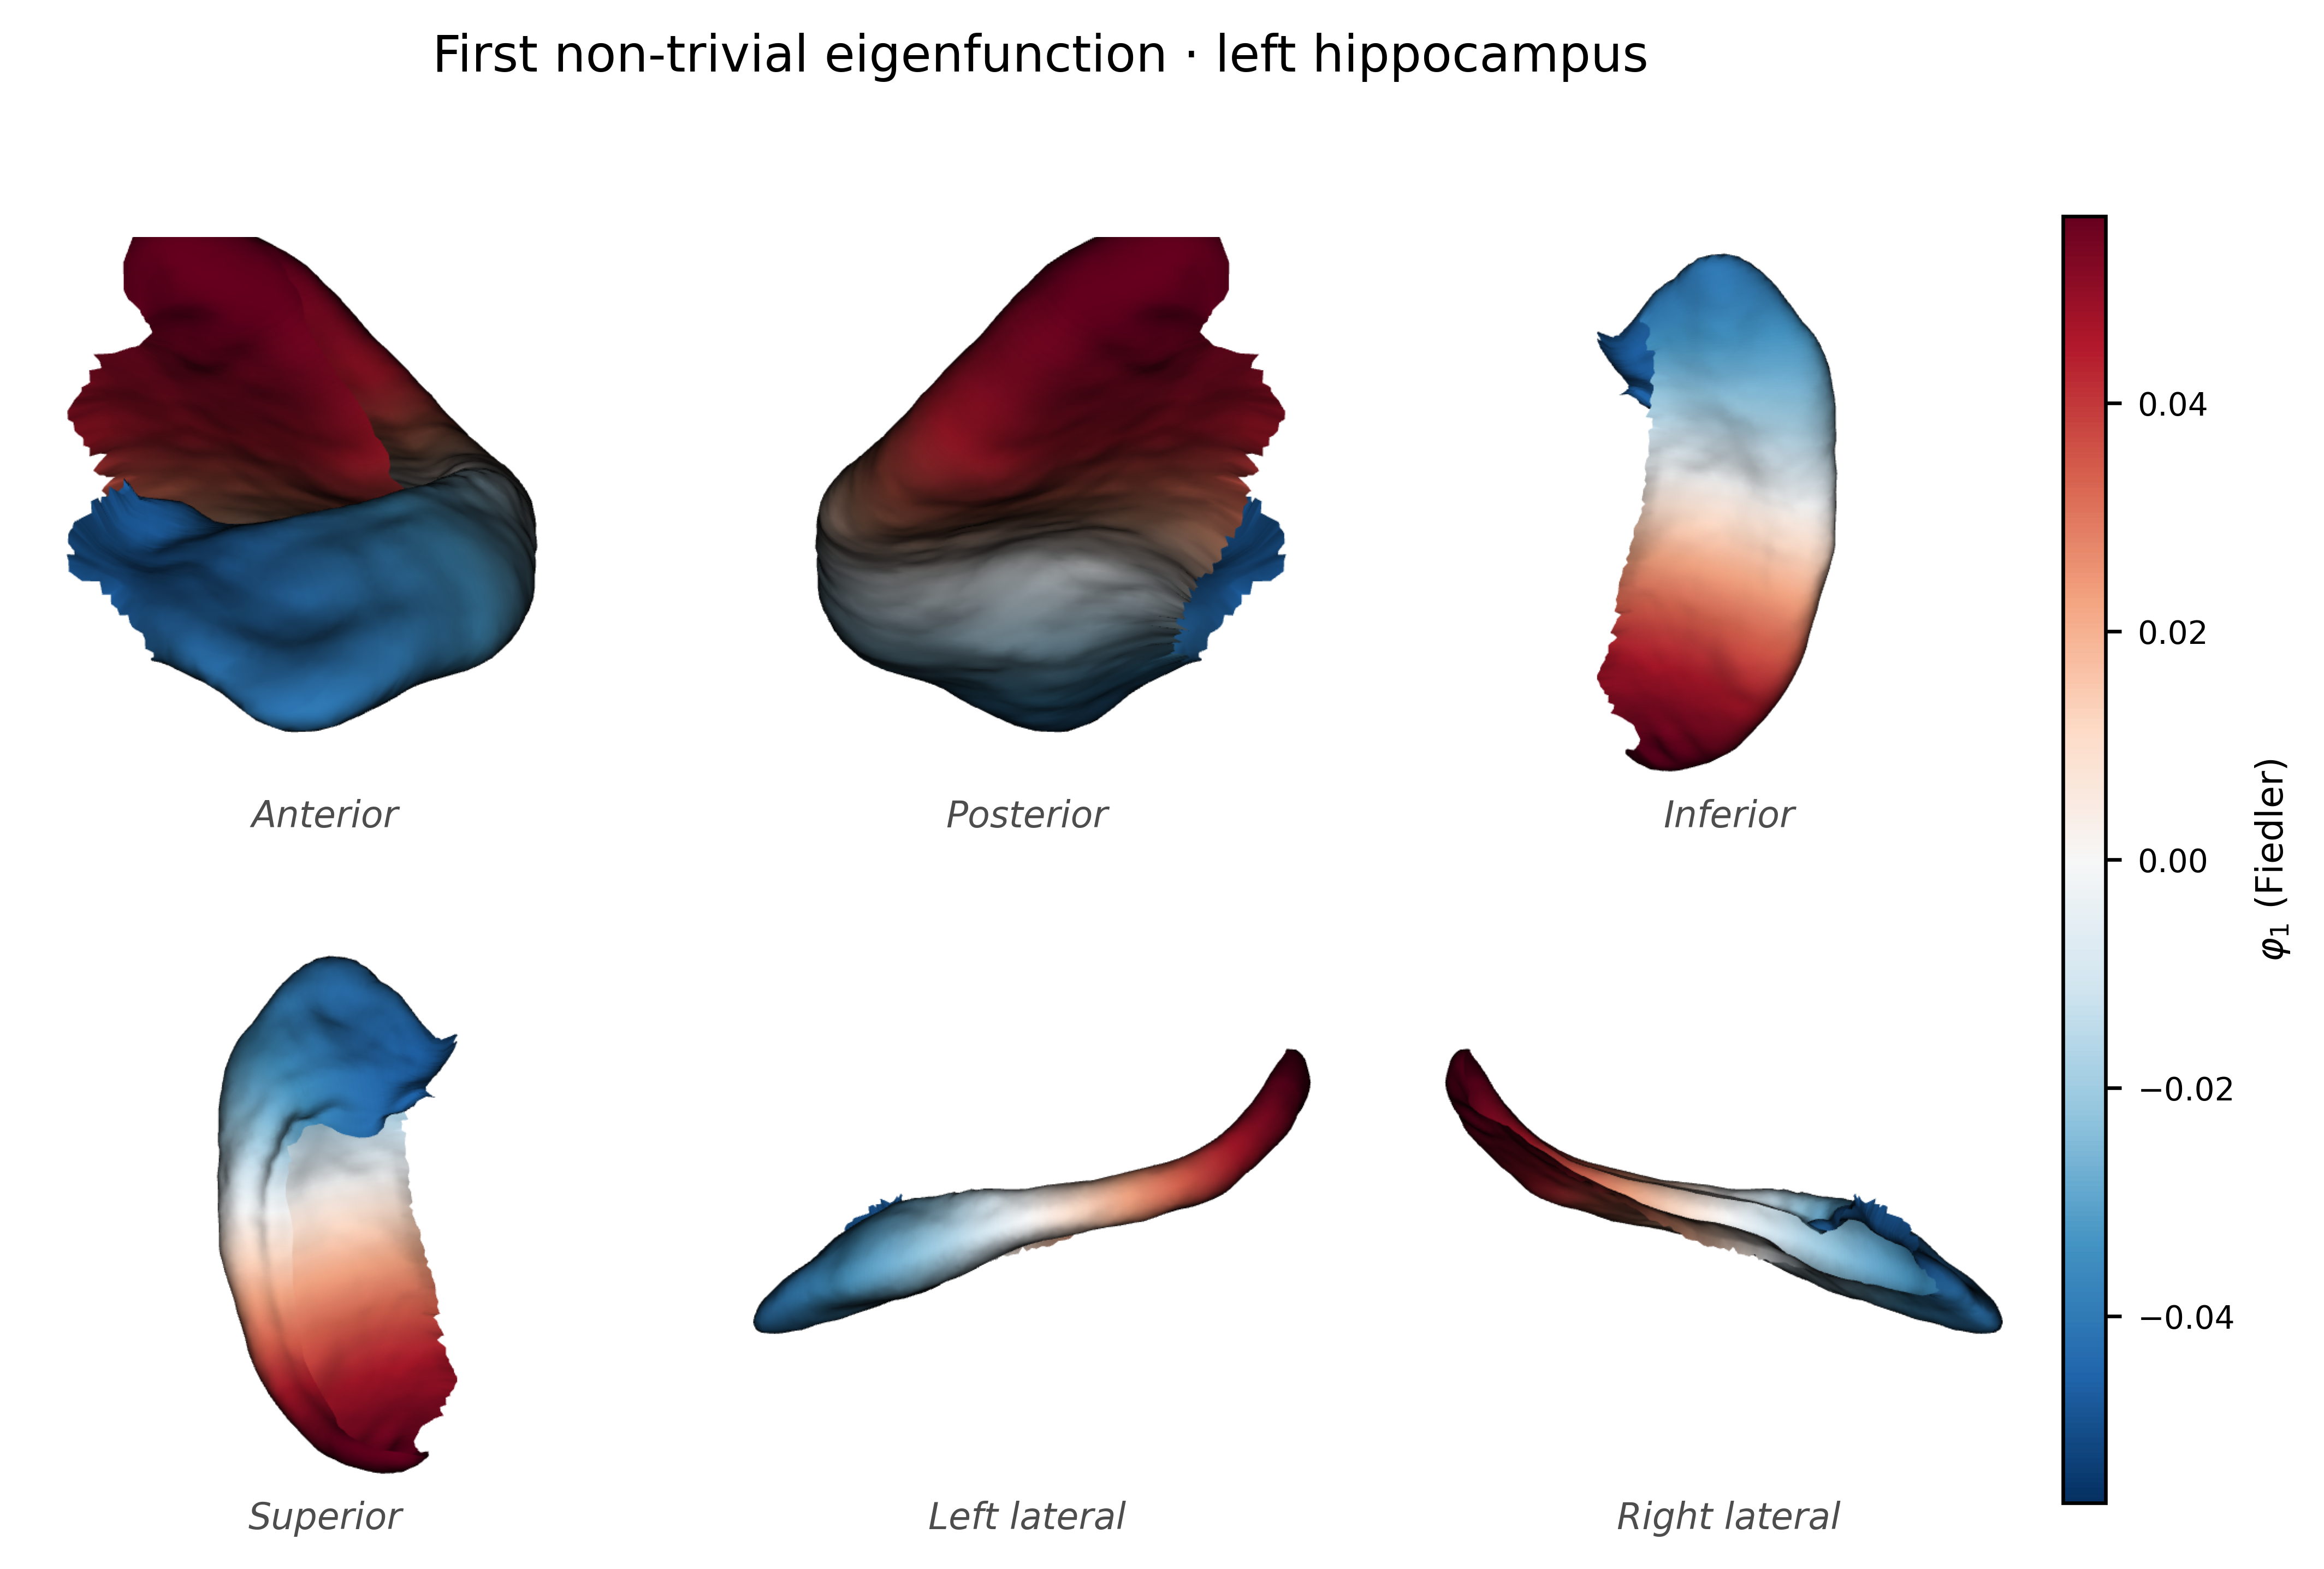

In [5]:
from spectralbrain.viz import plot_surface_sixview
fig = plot_surface_sixview(hipp, scalars=dec.eigenvectors[:, 1], cmap="RdBu_r",
                           signed=True, scalar_bar_title=r"$\varphi_1$ (Fiedler)",
                           title="First non-trivial eigenfunction · left hippocampus")
plt.show()

## 4. Weyl's law: the spectrum counts area

A theorem of Weyl (1911) says the eigenvalues of a 2-D domain grow **linearly**
with their index, at a rate set by the surface area $A$:

$$\lambda_k \;\sim\; \frac{4\pi}{A}\,k \qquad (k \to \infty).$$

This is why "you can hear the area of a drum." Let us check it on our hippocampus:
plot $\lambda_k$ against $k$ and overlay Weyl's prediction. The agreement is the
spectrum literally encoding the surface area we measured in section 1.

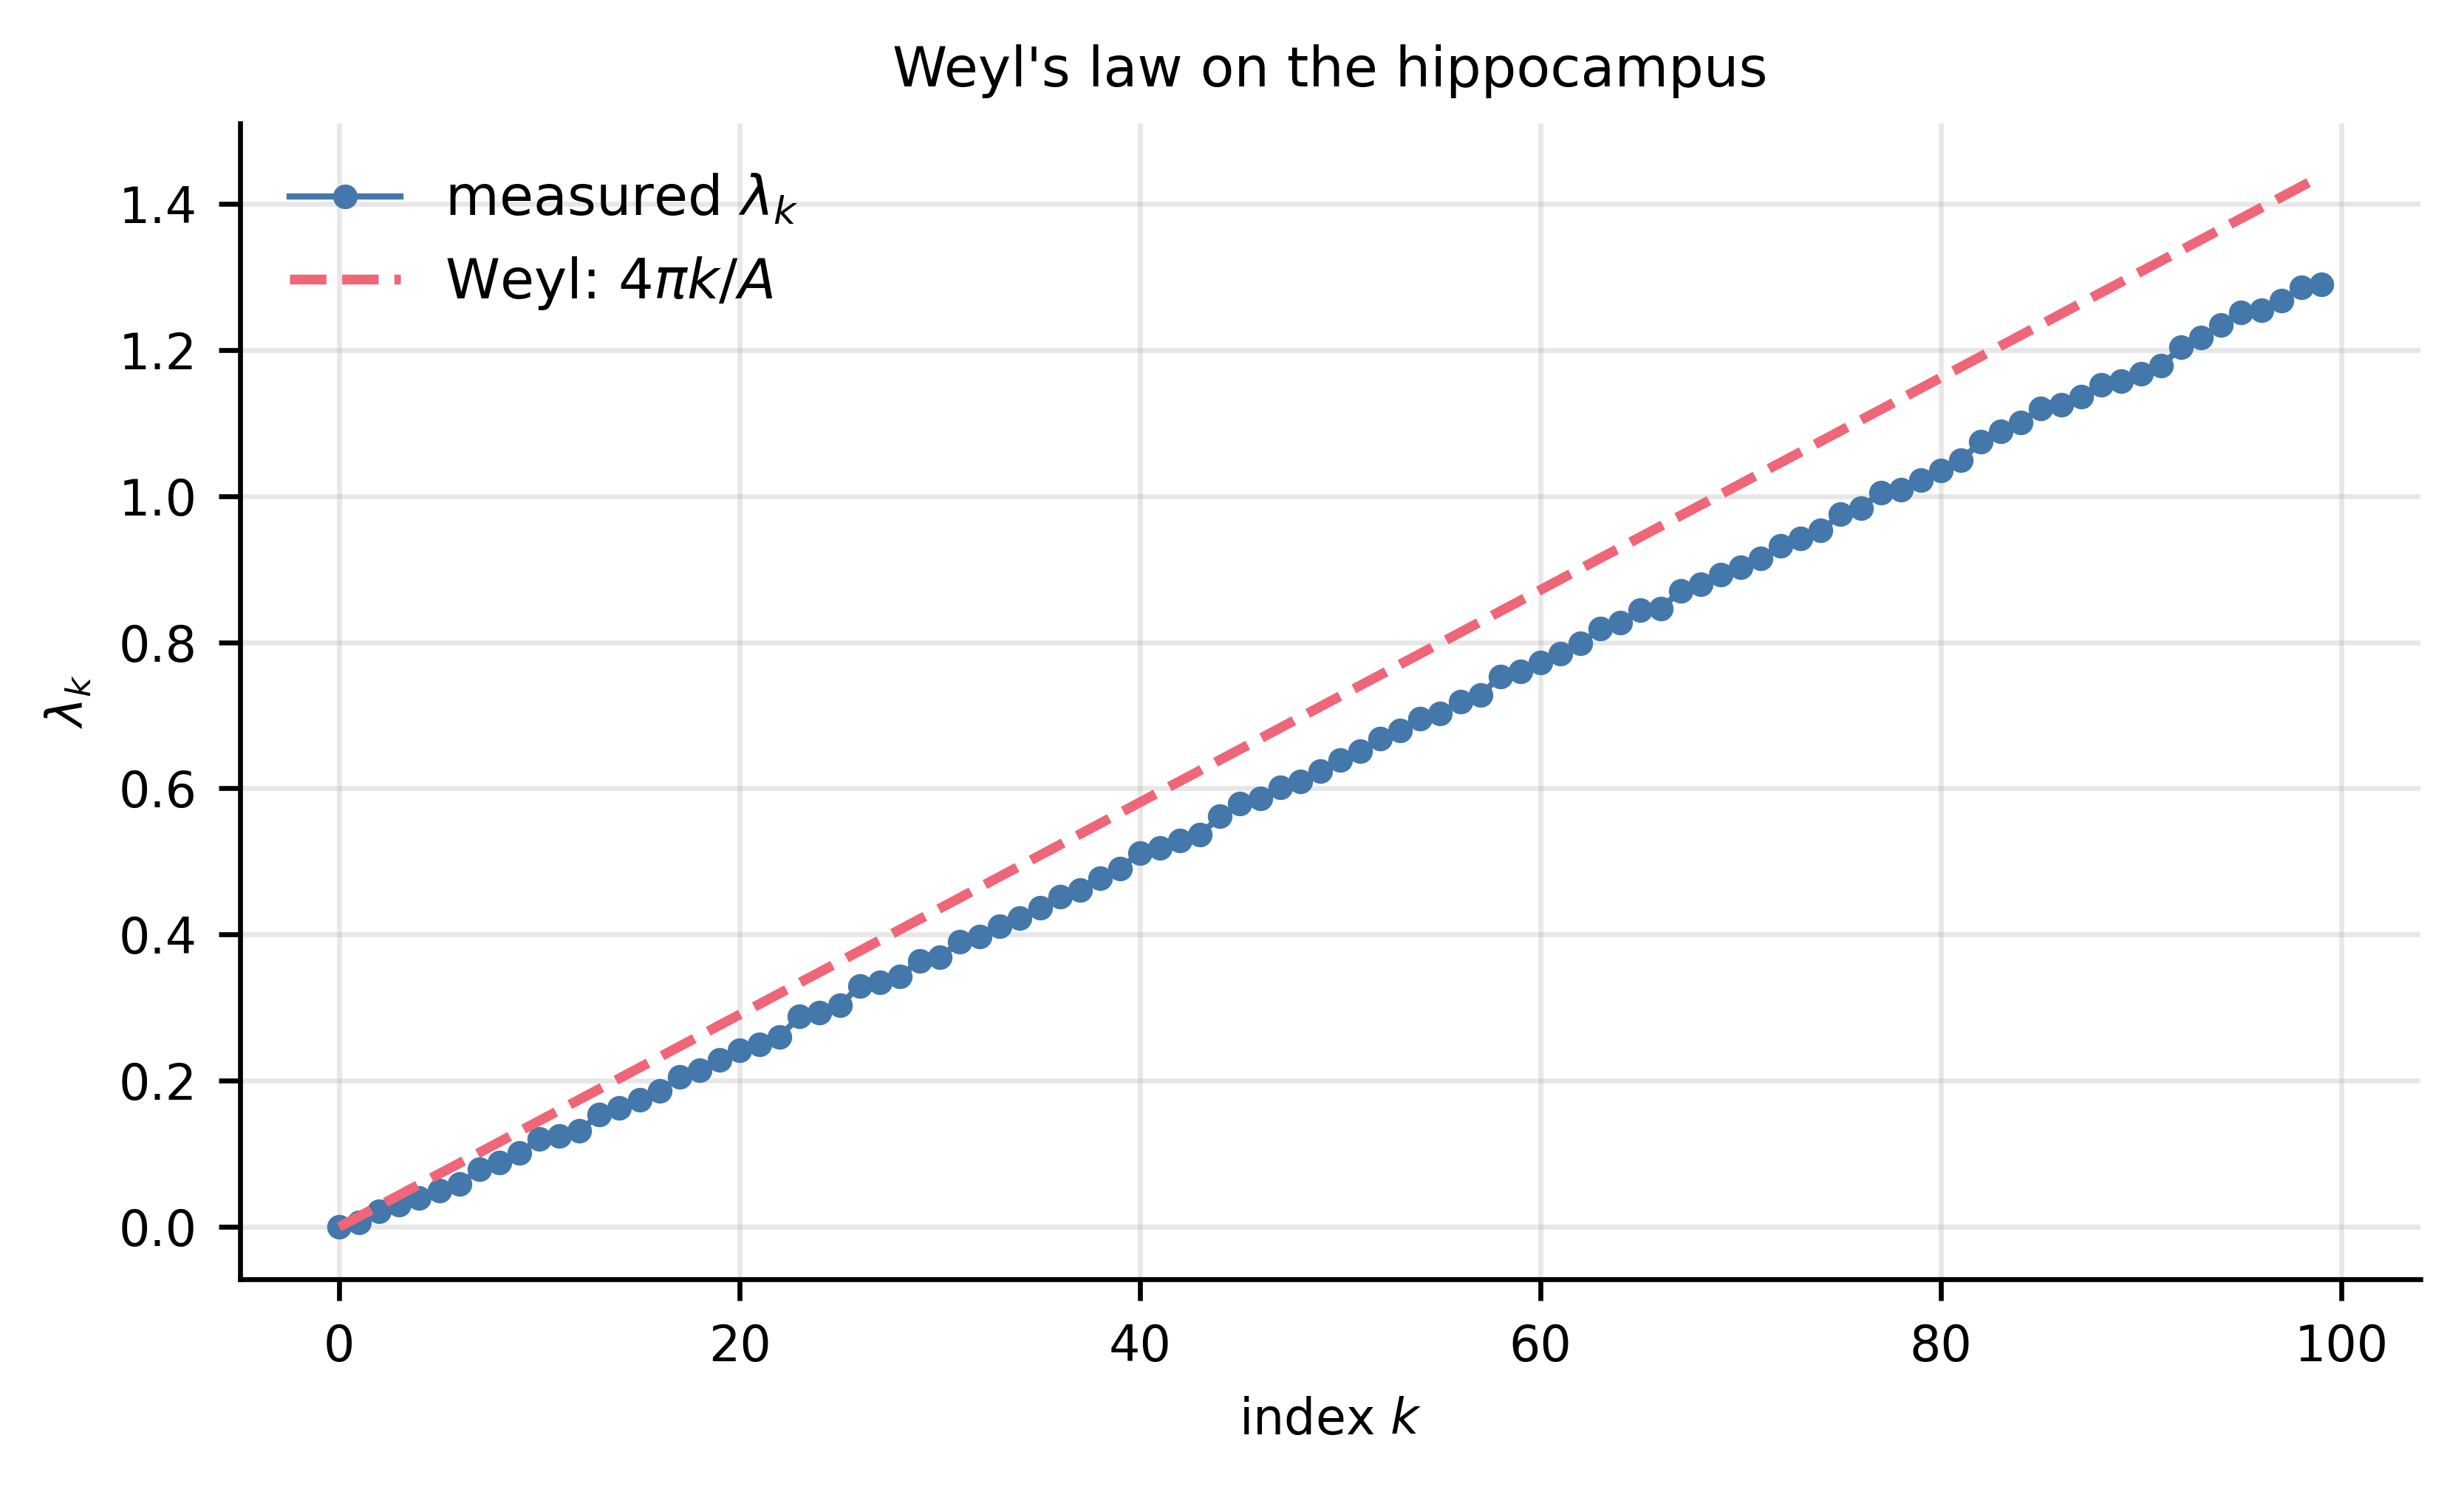

fitted slope         : 1.334e-02
Weyl prediction 4pi/A: 1.453e-02


In [6]:
k = np.arange(len(dec.eigenvalues))
weyl = 4 * np.pi * k / hipp.surface_area()

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(k, dec.eigenvalues, "o-", ms=3, lw=1, label=r"measured $\lambda_k$")
ax.plot(k, weyl, "--", lw=1.6, label=r"Weyl: $4\pi k / A$")
ax.set_xlabel("index $k$"); ax.set_ylabel(r"$\lambda_k$")
ax.set_title("Weyl's law on the hippocampus"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

slope = np.polyfit(k[10:], dec.eigenvalues[10:], 1)[0]
print(f"fitted slope         : {slope:.3e}")
print(f"Weyl prediction 4pi/A: {4*np.pi/hipp.surface_area():.3e}")

## 5. The payoff: isometry invariance

Here is the property that makes spectral descriptors special for neuroimaging.
Because $L$ and $M$ are built only from edge lengths and angles, **any rigid
motion of the brain — rotation, translation, reflection — leaves the spectrum
unchanged.** No registration, no alignment to a template is needed before
comparing shapes. Volume- and coordinate-based morphometry cannot say that.

We prove it: take the hippocampus, apply a random rotation and a translation,
re-run `decompose`, and compare the spectra. They should match to numerical
precision.

In [7]:
rng = np.random.default_rng(0)
# a random rotation matrix (QR of a random matrix gives an orthonormal R)
R, _ = np.linalg.qr(rng.normal(size=(3, 3)))
if np.linalg.det(R) < 0:
    R[:, 0] *= -1                      # keep it a proper rotation (det +1)
t = rng.normal(scale=50, size=3)       # arbitrary translation

moved = sb.BrainMesh(hipp.vertices @ R.T + t, hipp.faces)
dec_moved = moved.decompose(k=100)

max_diff = np.abs(dec.eigenvalues - dec_moved.eigenvalues).max()
print(f"centroid before : {hipp.vertices.mean(0)}")
print(f"centroid after  : {moved.vertices.mean(0)}")
print(f"max |Δλ| between original and rotated+translated spectrum: {max_diff:.3e}")
assert max_diff < 1e-6, "spectrum should be invariant to rigid motion!"
print("\n✓ The spectrum is invariant to pose — exactly as the theory predicts.")

[06/09/26 01:54:54] INFO     Laplacian (cotangent): N=8192, nnz=56578

centroid before : [-25.0152  12.4943  -4.9732]
centroid after  : [-60.3967 -42.5665  27.9181]
max |Δλ| between original and rotated+translated spectrum: 2.331e-15

✓ The spectrum is invariant to pose — exactly as the theory predicts.


## Exercises

1. **Resolution vs cost.** Time `hipp.decompose(k)` for `k` in `[25, 50, 100, 200]`
   (use `%timeit` or `time.perf_counter`). How does runtime scale? Does
   $\lambda_{10}$ change as you add more eigenvalues? (It should not — the small
   eigenvalues are stable.)
2. **Nodal count.** For $\varphi_1,\dots,\varphi_6$, count sign changes per vertex
   neighbourhood (or simply count connected positive/negative regions). Confirm
   that higher modes have more nodal domains (Courant's nodal domain theorem).
3. **Left vs right.** Load `sub03`'s **right** hippocampus, decompose it, and plot
   both spectra on one axis with `spectrum_plot`. Where do they diverge — low or
   high frequencies?
4. **Scale sensitivity.** Multiply the vertices by 2 (`hipp.vertices * 2`),
   re-decompose, and compare eigenvalues. They scale as $1/\text{area}$, i.e. by
   $1/4$. (Notebook 3 shows how ShapeDNA removes this scale factor.)
5. **A different structure.** Use `decompose` on a HippUnfold surface from `sub04`
   and compare its spectral gap (`dec.spectral_gap`) to `sub03`. 


## What's next

You can now turn any surface into a spectrum. But so far we used one pre-loaded
hippocampus. **Notebook 02** opens the I/O layer: FreeSurfer cortical surfaces,
`aseg` subcortical ROIs, hippocampal subfields, HippUnfold surfaces, and
white-matter tracts — the five subjects in `tutorials/data/` — and turns each of
them into a `BrainMesh` or `BrainPointCloud` ready for `decompose`.
